<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

# ¿Por qué utilizar Random Forest para este problema?

El modelo Random Forest es un algoritmo de ensemble basado en múltiples árboles de decisión que combina las predicciones de distintos árboles para generar un modelo más robusto y estable.

En este proyecto, el objetivo es clasificar el riesgo Urban Heat Island (UHI) (`No Risk` / `Risk`) utilizando variables espectrales, ambientales y topográficas obtenidas a partir de imágenes satelitales y datos geográficos.

Random Forest resulta especialmente adecuado para este caso porque:

- Maneja correctamente relaciones no lineales entre variables ambientales.
- Es robusto frente al ruido y variabilidad de los datos satelitales.
- Reduce el riesgo de sobreajuste al combinar múltiples árboles de decisión.
- Funciona bien con datasets tabulares de tamaño medio y gran cantidad de variables predictoras.
- Permite analizar la importancia de variables para interpretar qué factores influyen más en el riesgo térmico urbano.

Además, Random Forest tolera relativamente bien correlaciones entre variables y no requiere supuestos estadísticos estrictos sobre la distribución de los datos.

A diferencia de modelos como SVM, Random Forest no necesita escalado de variables, ya que basa su funcionamiento en particiones realizadas mediante árboles de decisión y no en distancias matemáticas.

Finalmente, se evaluará el impacto de incluir o eliminar las coordenadas geográficas (`latitude`, `longitude`) para analizar hasta qué punto el modelo depende de patrones espaciales explícitos frente a variables ambientales derivadas.

</div>

In [14]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Modelo XGBoost
import xgboost as xgb

# División del dataset y validación cruzada
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

# Modelos de Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# CARGA DEL DATASET DE MODELADO
# ============================================================

# Cargamos el dataset final preparado durante el EDA
# y el proceso de feature engineering.

df_bcn = pd.read_csv('../data/processed/dataset_modeling.csv')
df_bcn.shape

(69683, 14)

In [10]:
# ============================================================
# DEFINICIÓN DE FEATURES Y TARGET
# ============================================================

# Seleccionamos las variables predictoras que utilizaremos
# para entrenar el modelo Random Forest.

features_rf = [
    'latitude', 'longitude', 'elevation',
    'mndwi', 'nbr', 'ndbi', 'ndmi',
    'ndvi', 'ndwi', 'nir',
    'swir1', 'swir2',
    'season'
]

# Definimos el dataset de entrada (X)
# y la variable objetivo (y).

X_rf = df_bcn[features_rf]

y_rf = df_bcn['uhi_risk']

In [11]:
# ============================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

# Aplicamos One-Hot Encoding sobre la variable 'season'
# para evitar introducir relaciones ordinales artificiales.

X_rf = pd.get_dummies(
    X_rf,
    columns=['season'],
    drop_first=True
)

# Actualizamos la lista de variables tras la codificación.

updated_features_rf = X_rf.columns.tolist()

# Verificamos las columnas generadas.

print(updated_features_rf)

['latitude', 'longitude', 'elevation', 'mndwi', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'swir1', 'swir2', 'season_spring', 'season_summer', 'season_winter']


In [12]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# Dividimos el dataset en entrenamiento y prueba
# manteniendo el balance de clases.

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)

print(f"Dimensiones entrenamiento: {X_train_rf.shape[0]}")
print(f"Dimensiones prueba: {X_test_rf.shape[0]}")

Dimensiones entrenamiento: 55746
Dimensiones prueba: 13937


In [15]:
# ============================================================
# ENTRENAMIENTO RANDOM FOREST
# ============================================================

# Entrenamos el modelo Random Forest utilizando
# las variables espectrales, ambientales y espaciales.

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
# ============================================================
# EVALUACIÓN RANDOM FOREST
# ============================================================

# Evaluamos el rendimiento del modelo sobre
# el conjunto de prueba.

y_pred_rf = rf_model.predict(X_test_rf)

print("=" * 60)
print("CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 60)

print(
    classification_report(
        y_test_rf,
        y_pred_rf,
        target_names=['No Risk', 'Risk']
    )
)

CLASSIFICATION REPORT — RANDOM FOREST
              precision    recall  f1-score   support

     No Risk       0.69      0.68      0.69      6613
        Risk       0.72      0.73      0.72      7324

    accuracy                           0.71     13937
   macro avg       0.71      0.70      0.71     13937
weighted avg       0.71      0.71      0.71     13937



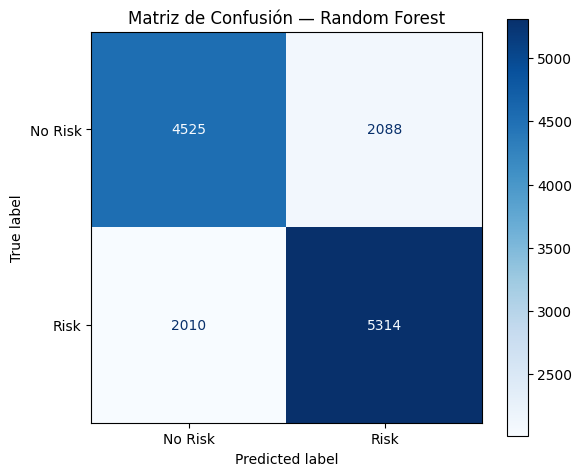

In [17]:
# ============================================================
# MATRIZ DE CONFUSIÓN RANDOM FOREST
# ============================================================

# Construimos la matriz de confusión para analizar
# los aciertos y errores de clasificación del modelo.

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_rf,
    y_pred_rf,
    display_labels=['No Risk', 'Risk'],
    cmap='Blues',
    ax=ax
)

ax.set_title('Matriz de Confusión — Random Forest')

plt.tight_layout()
plt.show()

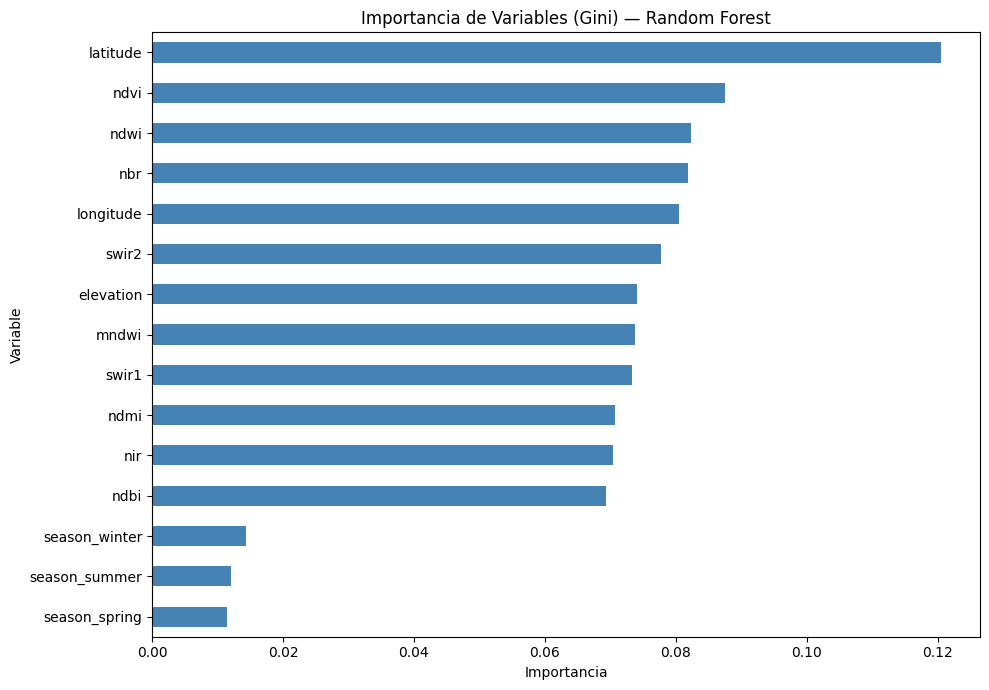

In [18]:
# ============================================================
# IMPORTANCIA DE VARIABLES RANDOM FOREST
# ============================================================

# Analizamos la importancia de variables utilizando
# el criterio Gini del modelo Random Forest.

importances_rf = pd.Series(
    rf_model.feature_importances_,
    index=updated_features_rf
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

importances_rf.plot(
    kind='barh',
    ax=ax,
    color='steelblue'
)

ax.set_title('Importancia de Variables (Gini) — Random Forest')
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')

plt.tight_layout()
plt.show()

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

# 💡 Observación — Selección del modelo final

Aunque el modelo Random Forest obtuvo resultados razonables para la clasificación del riesgo Urban Heat Island (UHI), finalmente no fue seleccionado como modelo final del proyecto.

Durante la comparación entre modelos, XGBoost mostró un mejor equilibrio general entre capacidad predictiva, estabilidad y rendimiento sobre la clase de riesgo térmico (`Risk`), especialmente en métricas como AUC-ROC y F1-score.

Además, XGBoost demostró una mejor capacidad para capturar relaciones complejas y no lineales entre variables espectrales, ambientales y topográficas, manteniendo una mayor robustez incluso al eliminar las coordenadas geográficas.

Otro aspecto importante es que XGBoost incorpora mecanismos avanzados de regularización (`reg_alpha`, `reg_lambda`) y optimización secuencial de árboles, lo que ayuda a reducir el sobreajuste y mejorar la generalización del modelo frente a datos no vistos.

Por este motivo, aunque Random Forest se utilizó como modelo de comparación y validación adicional dentro del análisis, el modelo finalmente seleccionado para el despliegue en Streamlit fue el modelo XGBoost optimizado.

</div>